## Example 1: Seismic Model Generation

This example demonstrates the use of **ModGen2D** to generate **multiple spatially correlated seismic property fields** for a typical **P-wave refraction scenario**. Refer **detailed version** for step-wise description.

### Model Replication and Automation
This **multiple version** of the example demonstrates how to generate multiple model realizations in a systematic and reproducible manner. For this and other examples, the individual cells from the **detailed version** can be consolidated into a single model-generation function. 

Multiple realizations can be generated efficiently by repeatedly calling the function with different model_id values by defining:
1. a random number generator (RNG) seed, and
2. a function parameterized by a model identifier (model_id),



This approach promotes reproducibility, scalability, and cleaner notebook structure, while preserving the same modeling logic presented in the detailed version.

In [1]:
import modgen2d as mg2d
import example1_helper_functions as hf


(<Axes: title={'center': 'Main_property_name:su'}, xlabel='X', ylabel='Z'>,
 np.float64(0.0),
 np.float64(48.82645540572896))

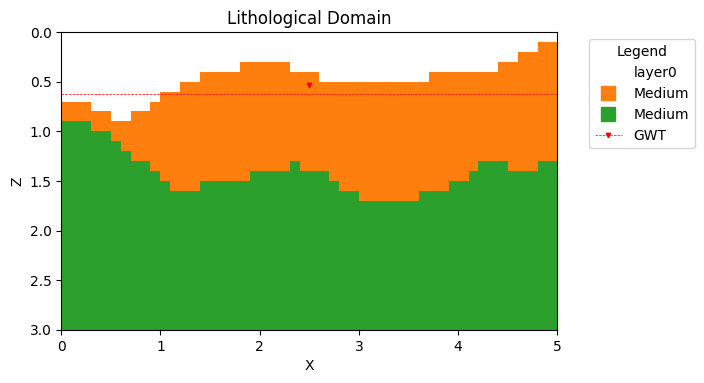

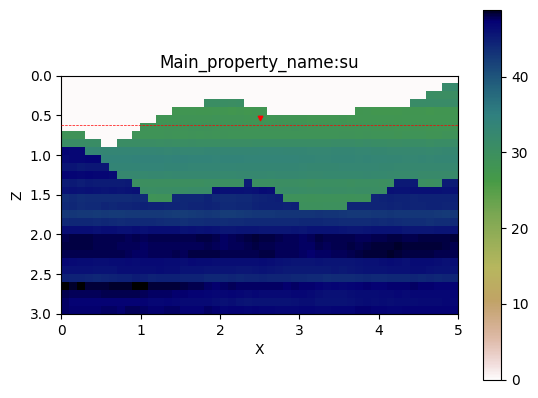

In [3]:
model_id = 1
to_h5 = f'generated_h5_files/{model_id:08d}.h5'

gen_profiles = mg2d.read_hdf5_file(to_h5)
gen_profiles.merged_generated_model2d.plot_lit_domain()
gen_profiles.merged_generated_model2d.plot_profile('su')

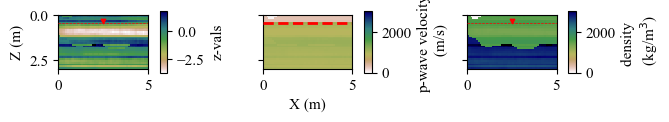

In [3]:
# Figure 7
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif']= ['Times New Roman'] + plt.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 11

fig, axs = plt.subplots(1, 3, figsize=(7, 10/4), sharex=True, sharey=True)

legendkwargs_dict = {
    'shrink':0.3,
    'aspect':8,
    'pad':0.1
}


ax = axs[0]
gen_profiles.merged_generated_model2d.plot_profile('z_vals_seismic', ax=ax, legend_label = 'z-vals', legendkwargs_dict=legendkwargs_dict)
ax.set(ylabel="Z (m)", xlabel=None, title=None)


ax = axs[1]
# compute Vp
vs_profile = gen_profiles.merged_generated_model2d.simulated_profiles['vs']
miu_profile = gen_profiles.merged_generated_model2d.simulated_profiles['miu']
vp_profile = hf.Vp_profile(vs_profile, miu_profile)
hf.plot_profile(gen_profiles.merged_generated_model2d, 'vs', vp_profile, ax=ax, vmin=0, vmax=3000, legend_label = 'p-wave velocity \n (m/s)', legendkwargs_dict=legendkwargs_dict)
ax.set(ylabel=None, xlabel="X (m)", title=None)


ax = axs[2]
gen_profiles.merged_generated_model2d.plot_profile('rho', ax=ax, vmin=0, vmax=3000, legend_label = 'density \n (kg/m$^3$)', legendkwargs_dict=legendkwargs_dict)
ax.set(ylabel=None, xlabel=None, title=None)

# ax = axs[1]
# gen_profiles.merged_generated_model2d.plot_profile('miu', ax=ax)

fig.tight_layout(rect=[0.05, 0.05, 1, 1])  # Leave space for shared labels
fig.savefig(r"F:\V_Tech Semesters\MS Thesis\Jupyter_MS\Papers_figures\Geomodgen2d_paper\Figure9_raw.svg", format="svg", bbox_inches='tight', metadata={'Creator':'Matplotlib'})

# ax.set(yscale='log', ylabel=None, xlabel=None, ylim=[0,1], title=None)


# gen_profiles.get_generated_model2d('z_vals_seismic')
